# Future Population Prediction (2026–2035)

This notebook predicts future population for 217 countries from 2026 to 2035 using the selected Linear Regression model.

Historical population data from 1960–2025 is used to generate recursive future predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("../data/processed/Global_Population_Cleaned.csv")

df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Population
0,Afghanistan,AFG,"Population, total",SP.POP.TOTL,1960,9035043.0
1,Afghanistan,AFG,"Population, total",SP.POP.TOTL,1961,9214083.0
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,1962,9404406.0
3,Afghanistan,AFG,"Population, total",SP.POP.TOTL,1963,9604487.0
4,Afghanistan,AFG,"Population, total",SP.POP.TOTL,1964,9814318.0


In [3]:
df = df.sort_values(["Country Code", "Year"]).copy()

df["Previous_Year_Population"] = (
    df.groupby("Country Code")["Population"].shift(1)
)

df["Population_Lag_2"] = (
    df.groupby("Country Code")["Population"].shift(2)
)

df["Previous_3Year_Avg"] = (
    df.groupby("Country Code")["Population"]
      .transform(
          lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
      )
)

df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Population,Previous_Year_Population,Population_Lag_2,Previous_3Year_Avg
594,Aruba,ABW,"Population, total",SP.POP.TOTL,1960,54922.0,NaN,NaN,NaN
595,Aruba,ABW,"Population, total",SP.POP.TOTL,1961,55578.0,54922.0,NaN,54922.000000
596,Aruba,ABW,"Population, total",SP.POP.TOTL,1962,56320.0,55578.0,54922.0,55250.000000
597,Aruba,ABW,"Population, total",SP.POP.TOTL,1963,57002.0,56320.0,55578.0,55606.666667
598,Aruba,ABW,"Population, total",SP.POP.TOTL,1964,57619.0,57002.0,56320.0,56300.000000


In [4]:
features = [
    "Year",
    "Previous_Year_Population",
    "Population_Lag_2",
    "Previous_3Year_Avg"
]

target = "Population"

model_df = df.dropna(
    subset=[
        "Previous_Year_Population",
        "Population_Lag_2",
        "Previous_3Year_Avg"
    ]
).copy()

X_train = model_df[features]
y_train = model_df[target]

print("Training Data:", X_train.shape)
print("Target Data:", y_train.shape)
print("Training Years:", model_df["Year"].min(), "-", model_df["Year"].max())

Training Data: (13858, 4)
Target Data: (13858,)
Training Years: 1962 - 2025


In [5]:
final_model = LinearRegression()

final_model.fit(X_train, y_train)

print("Final Linear Regression model trained successfully.")

Final Linear Regression model trained successfully.


2026–2035 Recursive Future Prediction

In [6]:
future_predictions = []

future_years = range(2026, 2036)

for country_code in df["Country Code"].unique():

    country_data = (
        df[df["Country Code"] == country_code]
        .sort_values("Year")
        .copy()
    )

    country_name = country_data["Country Name"].iloc[0]

    # Historical population values up to 2025
    history = country_data["Population"].tolist()

    for year in future_years:

        previous_year_population = history[-1]
        population_lag_2 = history[-2]
        previous_3year_avg = np.mean(history[-3:])

        X_future = pd.DataFrame(
            [[
                year,
                previous_year_population,
                population_lag_2,
                previous_3year_avg
            ]],
            columns=features
        )

        predicted_population = final_model.predict(X_future)[0]

        future_predictions.append({
            "Country Name": country_name,
            "Country Code": country_code,
            "Year": year,
            "Predicted_Population": predicted_population
        })

        # Add prediction to history for the next year's prediction
        history.append(predicted_population)

future_df = pd.DataFrame(future_predictions)

future_df.head(10)

,Country Name,Country Code,Year,Predicted_Population
0,Aruba,ABW,2026,105710.238986
1,Aruba,ABW,2027,98266.908410
2,Aruba,ABW,2028,86206.059703
3,Aruba,ABW,2029,69299.410686
4,Aruba,ABW,2030,47322.482575
5,Aruba,ABW,2031,20053.347049
6,Aruba,ABW,2032,-12727.504856
7,Aruba,ABW,2033,-51237.212640
8,Aruba,ABW,2034,-95690.589745
9,Aruba,ABW,2035,-146300.165878


In [7]:
print("Future Prediction Shape:", future_df.shape)
print("Countries:", future_df["Country Code"].nunique())
print("Years:", future_df["Year"].min(), "-", future_df["Year"].max())

Future Prediction Shape: (2170, 4)
Countries: 217
Years: 2026 - 2035


In [8]:
future_df.to_csv(
    "../outputs/tables/future_population_predictions_2026_2035.csv",
    index=False
)

print("Future population predictions saved successfully.")

Future population predictions saved successfully.


In [9]:
global_future = (
    future_df
    .groupby("Year")["Predicted_Population"]
    .sum()
    .reset_index()
)

global_future["Population_Billions"] = (
    global_future["Predicted_Population"] / 1e9
)

global_future

,Year,Predicted_Population,Population_Billions
0,2026,8.265216e+09,8.265216
1,2027,8.336997e+09,8.336997
2,2028,8.407389e+09,8.407389
3,2029,8.476354e+09,8.476354
4,2030,8.543853e+09,8.543853
5,2031,8.609846e+09,8.609846
6,2032,8.674294e+09,8.674294
7,2033,8.737160e+09,8.737160
8,2034,8.798404e+09,8.798404
9,2035,8.857991e+09,8.857991


Future Population Prediction Chart

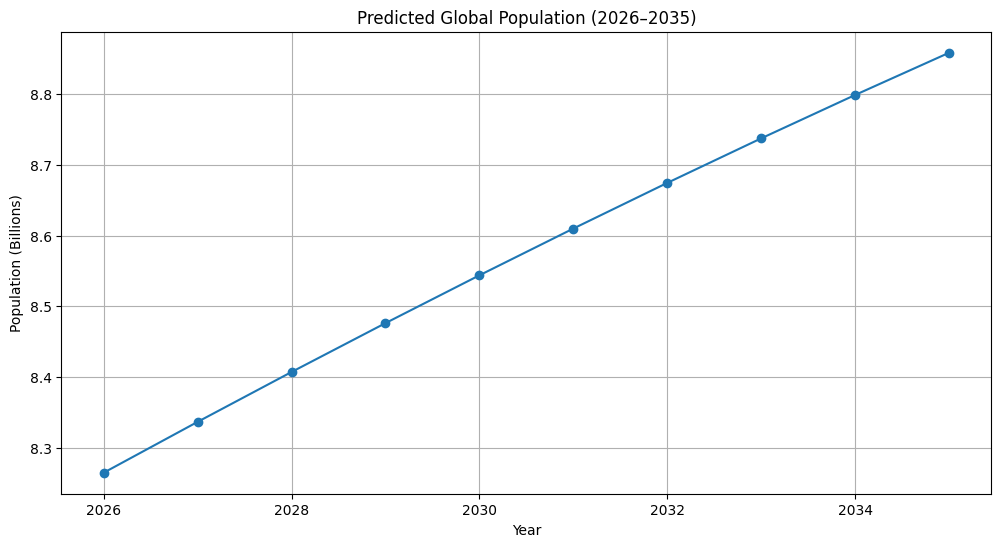

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(
    global_future["Year"],
    global_future["Population_Billions"],
    marker="o"
)

plt.title("Predicted Global Population (2026–2035)")
plt.xlabel("Year")
plt.ylabel("Population (Billions)")
plt.grid(True)

plt.savefig(
    "../outputs/figures/future_global_population_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
prediction_2035 = global_future[
    global_future["Year"] == 2035
]

prediction_2035

,Year,Predicted_Population,Population_Billions
9,2035,8.857991e+09,8.857991


In [12]:
population_2035 = prediction_2035["Population_Billions"].iloc[0]

print(
    f"Predicted Global Population in 2035: "
    f"{population_2035:.3f} billion"
)

Predicted Global Population in 2035: 8.858 billion


## Key Finding

The Linear Regression model predicts that the global population will reach approximately **8.858 billion people by 2035**.

The forecast shows a continuous increase in global population from approximately **8.265 billion in 2026** to **8.858 billion in 2035**.

# STEP 10 — Country-Level Future Prediction Analysis

This section analyzes future population predictions for selected countries from 2026 to 2035.

In [13]:
selected_countries = [
    "Sri Lanka",
    "India",
    "China",
    "United States"
]

country_future = future_df[
    future_df["Country Name"].isin(selected_countries)
].copy()

country_future.head()

,Country Name,Country Code,Year,Predicted_Population
360,China,CHN,2026,1.404254e+09
361,China,CHN,2027,1.402032e+09
362,China,CHN,2028,1.399921e+09
363,China,CHN,2029,1.397919e+09
364,China,CHN,2030,1.396024e+09


In [14]:
print("Selected Countries:")
print(country_future["Country Name"].unique())

print("\nNumber of records:", len(country_future))

Selected Countries:
['China' 'India' 'Sri Lanka' 'United States']

Number of records: 40


In [15]:
country_future["Predicted_Population_Millions"] = (
    country_future["Predicted_Population"] / 1e6
)

country_future.head()

,Country Name,Country Code,Year,Predicted_Population,Predicted_Population_Millions
360,China,CHN,2026,1.404254e+09,1404.254216
361,China,CHN,2027,1.402032e+09,1402.032232
362,China,CHN,2028,1.399921e+09,1399.920923
363,China,CHN,2029,1.397919e+09,1397.918766
364,China,CHN,2030,1.396024e+09,1396.024021


Country-Level Prediction Table

In [16]:
country_prediction_table = country_future[
    [
        "Country Name",
        "Year",
        "Predicted_Population_Millions"
    ]
].sort_values(
    ["Country Name", "Year"]
)

country_prediction_table

,Country Name,Year,Predicted_Population_Millions
360,China,2026,1404.254216
361,China,2027,1402.032232
362,China,2028,1399.920923
363,China,2029,1397.918766
364,China,2030,1396.024021
365,China,2031,1394.234957
366,China,2032,1392.549871
367,China,2033,1390.967088
368,China,2034,1389.484959
369,China,2035,1388.101862


In [17]:
country_2035 = country_future[
    country_future["Year"] == 2035
].sort_values(
    "Predicted_Population",
    ascending=False
)

country_2035[
    [
        "Country Name",
        "Year",
        "Predicted_Population_Millions"
    ]
]

,Country Name,Year,Predicted_Population_Millions
899,India,2035,1589.525932
369,China,2035,1388.101862
2039,United States,2035,358.267998
1139,Sri Lanka,2035,20.038529


Country-Level Trend Chart

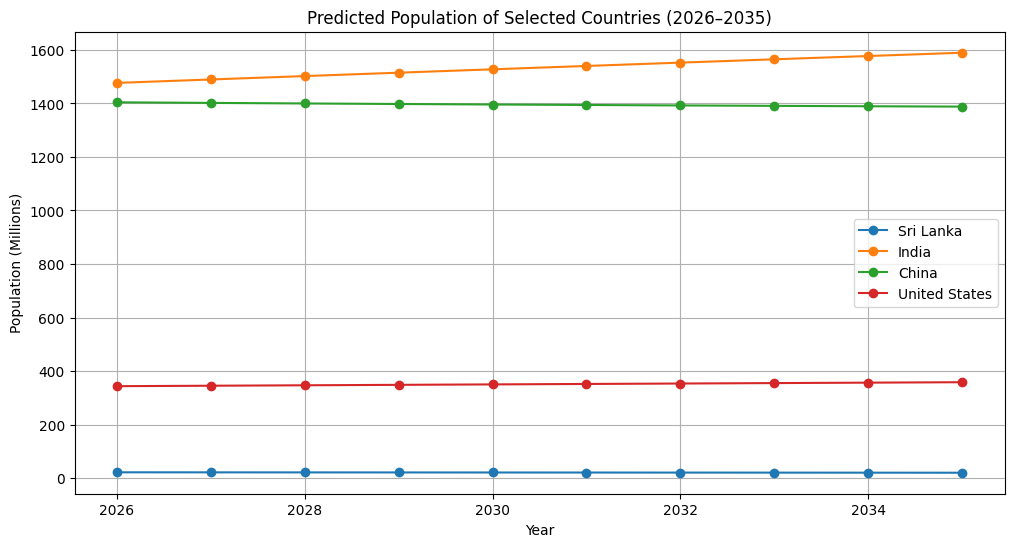

In [18]:
plt.figure(figsize=(12, 6))

for country in selected_countries:
    country_data = country_future[
        country_future["Country Name"] == country
    ]

    plt.plot(
        country_data["Year"],
        country_data["Predicted_Population_Millions"],
        marker="o",
        label=country
    )

plt.title("Predicted Population of Selected Countries (2026–2035)")
plt.xlabel("Year")
plt.ylabel("Population (Millions)")
plt.legend()
plt.grid(True)

plt.savefig(
    "../outputs/figures/selected_countries_future_population.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

All Countries Growth

In [19]:
all_country_growth = (
    future_df
    .sort_values(["Country Code", "Year"])
    .groupby(["Country Name", "Country Code"])
    .agg(
        Population_2026=("Predicted_Population", "first"),
        Population_2035=("Predicted_Population", "last")
    )
    .reset_index()
)

all_country_growth["Growth_Millions"] = (
    all_country_growth["Population_2035"]
    - all_country_growth["Population_2026"]
) / 1e6

all_country_growth["Growth_Percentage"] = (
    (
        all_country_growth["Population_2035"]
        - all_country_growth["Population_2026"]
    )
    / all_country_growth["Population_2026"]
) * 100

all_country_growth.head()

,Country Name,Country Code,Population_2026,Population_2035,Growth_Millions,Growth_Percentage
0,Afghanistan,AFG,4.502596e+07,5.493217e+07,9.906209,22.001107
1,Albania,ALB,2.319108e+06,1.841445e+06,-0.477663,-20.596844
2,Algeria,DZA,4.804602e+07,5.312200e+07,5.075983,10.564835
3,American Samoa,ASM,4.143259e+04,-2.236469e+05,-0.265079,-639.784989
4,Andorra,AND,7.998256e+04,-1.708124e+05,-0.250795,-313.562106


In [20]:
top_growth_countries = all_country_growth.sort_values(
    "Growth_Percentage",
    ascending=False
).head(10)

top_growth_countries

,Country Name,Country Code,Population_2026,Population_2035,Growth_Millions,Growth_Percentage
166,Saudi Arabia,SAU,3.863128e+07,5.255356e+07,13.922275,36.038864
204,United Arab Emirates,ARE,1.203236e+07,1.623735e+07,4.204991,34.947347
189,Syrian Arab Republic,SYR,2.654558e+07,3.422104e+07,7.675460,28.914263
148,Oman,OMN,5.700489e+06,7.231838e+06,1.531349,26.863459
44,"Congo, Dem. Rep.",COD,1.163555e+08,1.462876e+08,29.932120,25.724710
176,"Somalia, Fed. Rep.",SOM,2.028984e+07,2.549755e+07,5.207708,25.666581
38,Chad,TCD,2.167801e+07,2.720894e+07,5.530924,25.513982
143,Niger,NER,2.879176e+07,3.604617e+07,7.254416,25.196157
203,Ukraine,UKR,4.015650e+07,5.004702e+07,9.890521,24.629938
5,Angola,AGO,4.018068e+07,4.972534e+07,9.544660,23.754352


In [21]:
all_country_growth.to_csv(
    "../outputs/tables/all_country_future_population_growth.csv",
    index=False
)

print("All-country future growth analysis saved successfully.")

All-country future growth analysis saved successfully.


In [22]:
dashboard_data = future_df.copy()

dashboard_data["Predicted_Population_Millions"] = (
    dashboard_data["Predicted_Population"] / 1e6
)

dashboard_data.head()

,Country Name,Country Code,Year,Predicted_Population,Predicted_Population_Millions
0,Aruba,ABW,2026,105710.238986,0.105710
1,Aruba,ABW,2027,98266.908410,0.098267
2,Aruba,ABW,2028,86206.059703,0.086206
3,Aruba,ABW,2029,69299.410686,0.069299
4,Aruba,ABW,2030,47322.482575,0.047322


In [23]:
dashboard_data.to_csv(
    "../outputs/tables/dashboard_future_predictions.csv",
    index=False
)

print("Dashboard dataset saved successfully.")

Dashboard dataset saved successfully.
